Cell 0 — Imports + paths + load index

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

INDEX_PATH = Path("data/processed/inbreast_index.csv")
assert INDEX_PATH.exists(), f"Missing {INDEX_PATH}"

df = pd.read_csv(INDEX_PATH)

print("Index rows:", len(df))
print("Columns:", list(df.columns))
df.head(3)

Index rows: 409
Columns: ['file_id', 'dicom_path', 'Patient ID', 'Patient age', 'Laterality', 'View', 'Acquisition date', 'ACR', 'tissue_binary', 'Bi-Rads', 'Mass ', 'Micros', 'Distortion', 'Asymmetry', 'Lesion Annotation Status']


,file_id,dicom_path,Patient ID,Patient age,Laterality,View,Acquisition date,ACR,tissue_binary,Bi-Rads,Mass,Micros,Distortion,Asymmetry,Lesion Annotation Status
0,22678622,data\raw\inbreast\ALL-IMGS\22678622_61b13c59bc...,removed,removed,R,CC,201001.0,4.0,1,1,NaN,NaN,NaN,NaN,No annotation (Normal)
1,22678646,data\raw\inbreast\ALL-IMGS\22678646_61b13c59bc...,removed,removed,L,CC,201001.0,4.0,1,3,X,NaN,NaN,NaN,NaN
2,22678670,data\raw\inbreast\ALL-IMGS\22678670_61b13c59bc...,removed,removed,R,MLO,201001.0,4.0,1,1,NaN,NaN,NaN,NaN,No annotation (Normal)


Cell 1 — Clean columns + make a stable label

In [2]:
# Standardise column names
df.columns = [c.strip() for c in df.columns]

# Basic cleaning
df = df.dropna(subset=["dicom_path", "Patient ID", "ACR"]).copy()
df["Patient ID"] = df["Patient ID"].astype(str)
df["ACR"] = pd.to_numeric(df["ACR"], errors="coerce")
df = df[df["ACR"].isin([1,2,3,4])].copy()

# Tissue label: 0 = ACR 1-2 (fatty/non-dense), 1 = ACR 3-4 (fibroglandular/dense)
df["y_tissue"] = (df["ACR"] >= 3).astype(int)

print("After cleaning:", len(df))
print(df["ACR"].value_counts().sort_index())
print(df["y_tissue"].value_counts())

After cleaning: 409
ACR
1.0    136
2.0    146
3.0     99
4.0     28
Name: count, dtype: int64
y_tissue
0    282
1    127
Name: count, dtype: int64


Cell 2 — Create the two “Stage 1 datasets”

In [3]:
# Tissue dataset
tissue_df = df.copy()

# If you want "pure tissue texture", optionally exclude rows flagged as mass:
if "Mass" in tissue_df.columns:
    tissue_df = tissue_df[~(tissue_df["Mass"].astype(str).str.upper() == "X")].copy()

print("Tissue rows:", len(tissue_df))
print("Tissue class balance:", tissue_df["y_tissue"].value_counts().to_dict())


mass_df = None
if "Mass" in df.columns:
    mass_df = df[df["Mass"].astype(str).str.upper() == "X"].copy()
    print("Mass-present rows:", len(mass_df))
else:
    print("No Mass column found in index — skipping mass dataset.")

Tissue rows: 301
Tissue class balance: {0: 202, 1: 99}
Mass-present rows: 108


In [4]:
import numpy as np
import json
from sklearn.model_selection import StratifiedGroupKFold
from pathlib import Path

OUT_SPLITS = Path("data/processed/splits")
OUT_SPLITS.mkdir(parents=True, exist_ok=True)

def make_folds(df_in, label_col, group_col="Patient ID", n_splits=10, seed=42):
    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    X = np.arange(len(df_in))
    y = df_in[label_col].values
    g = df_in[group_col].astype(str).values

    folds = []
    for k, (tr, te) in enumerate(sgkf.split(X, y, g)):
        folds.append({"fold": k, "train_idx": tr.tolist(), "test_idx": te.tolist()})
    return folds

# Tissue splits
folds_tissue = make_folds(tissue_df, label_col="y_tissue")
with open(OUT_SPLITS / "tissue_10fold.json", "w") as f:
    json.dump(folds_tissue, f)

print("Saved tissue splits:", (OUT_SPLITS / "tissue_10fold.json").resolve())

# Mass splits (label = Bi-Rads threshold is NOT decided yet; for Stage 1 we can stratify by a proxy)
# For now: stratify by "has mass" is trivial (all are mass), so instead stratify by BI-RADS grouping if present
if mass_df is not None and "Bi-Rads" in mass_df.columns:
    # Make a simple strat label that works with strings like 4a/4b/4c
    b = mass_df["Bi-Rads"].astype(str).str.lower()
    mass_df = mass_df.copy()
    mass_df["birads_group"] = b.str.extract(r"(\d)")[0].fillna("na")
    folds_mass = make_folds(mass_df, label_col="birads_group")  # stratify by birads_group
    with open(OUT_SPLITS / "mass_10fold.json", "w") as f:
        json.dump(folds_mass, f)
    print("Saved mass splits:", (OUT_SPLITS / "mass_10fold.json").resolve())
else:
    print("Skipping mass splits (mass_df missing or Bi-Rads missing).")

Saved tissue splits: \\wsl$\Ubuntu\home\nabeel\project34\Project34\data\processed\splits\tissue_10fold.json
Saved mass splits: \\wsl$\Ubuntu\home\nabeel\project34\Project34\data\processed\splits\mass_10fold.json


c:\Users\nabee\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:1023: UserWarning: The least populated class in y has only 8 members, which is less than n_splits=10.
  warnings.warn(


In [5]:
import numpy as np
import pydicom
from pydicom.pixel_data_handlers.util import apply_voi_lut
from PIL import Image

def load_normalized_mammo(dicom_path: str) -> np.ndarray:
    ds = pydicom.dcmread(dicom_path)
    img = ds.pixel_array.astype(np.float32)

    try:
        img = apply_voi_lut(img, ds).astype(np.float32)
    except Exception:
        pass

    if getattr(ds, "PhotometricInterpretation", "") == "MONOCHROME1":
        img = img.max() - img

    lo, hi = np.percentile(img, (1, 99))
    img = np.clip(img, lo, hi)
    img = (img - lo) / (hi - lo + 1e-8)
    return img

def crop_to_breast(img01: np.ndarray, thresh: float = 0.05, pad: int = 10) -> np.ndarray:
    mask = img01 > thresh
    ys, xs = np.where(mask)
    if len(xs) == 0:
        return img01
    x0, x1 = xs.min(), xs.max()
    y0, y1 = ys.min(), ys.max()
    x0 = max(0, x0 - pad); x1 = min(img01.shape[1], x1 + pad)
    y0 = max(0, y0 - pad); y1 = min(img01.shape[0], y1 + pad)
    return img01[y0:y1, x0:x1]

def resize_img(img01: np.ndarray, size=(512, 512)) -> np.ndarray:
    im = Image.fromarray((img01 * 255).astype(np.uint8))
    im = im.resize(size, resample=Image.BILINEAR)
    return (np.asarray(im).astype(np.float32) / 255.0)

def preprocess_full(dicom_path: str, size=(512, 512)) -> np.ndarray:
    img = load_normalized_mammo(dicom_path)
    img = crop_to_breast(img)
    img = resize_img(img, size=size)
    return img

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd

def sample_patches(img01: np.ndarray, n_patches=10, patch=128, seed=0):
    rng = np.random.default_rng(seed)
    H, W = img01.shape
    if H < patch or W < patch:
        return []

    mask = img01 > 0.05
    ys, xs = np.where(mask)
    if len(xs) == 0:
        return []

    patches = []
    for _ in range(n_patches):
        j = rng.integers(0, len(xs))
        cy, cx = int(ys[j]), int(xs[j])
        y0 = int(np.clip(cy - patch//2, 0, H - patch))
        x0 = int(np.clip(cx - patch//2, 0, W - patch))
        patches.append(img01[y0:y0+patch, x0:x0+patch])
    return patches

PATCH_DIR = Path("data/processed/tissue_patches_128")
PATCH_DIR.mkdir(parents=True, exist_ok=True)

records = []
patch_id = 0

# Start with 50 images for a quick test; set to len(tissue_df) when happy
N_IMAGES = min(50, len(tissue_df))

for idx, row in tissue_df.head(N_IMAGES).iterrows():
    img = preprocess_full(row["dicom_path"], size=(512, 512))
    pts = sample_patches(img, n_patches=10, patch=128, seed=idx)

    for p in pts:
        np.save(PATCH_DIR / f"{patch_id}.npy", p)
        records.append({
            "patch_id": patch_id,
            "source_row": idx,
            "patient_id": row["Patient ID"],
            "y_tissue": int(row["y_tissue"]),
            "view": row.get("View", None),
            "laterality": row.get("Laterality", None),
        })
        patch_id += 1

patch_df = pd.DataFrame(records)
patch_df.to_csv(PATCH_DIR / "tissue_patches.csv", index=False)

print("Saved patches:", len(patch_df))
print("Saved CSV:", (PATCH_DIR / "tissue_patches.csv").resolve())
patch_df.head()

Saved patches: 500
Saved CSV: \\wsl$\Ubuntu\home\nabeel\project34\Project34\data\processed\tissue_patches_128\tissue_patches.csv


,patch_id,source_row,patient_id,y_tissue,view,laterality
0,0,0,removed,1,CC,R
1,1,0,removed,1,CC,R
2,2,0,removed,1,CC,R
3,3,0,removed,1,CC,R
4,4,0,removed,1,CC,R


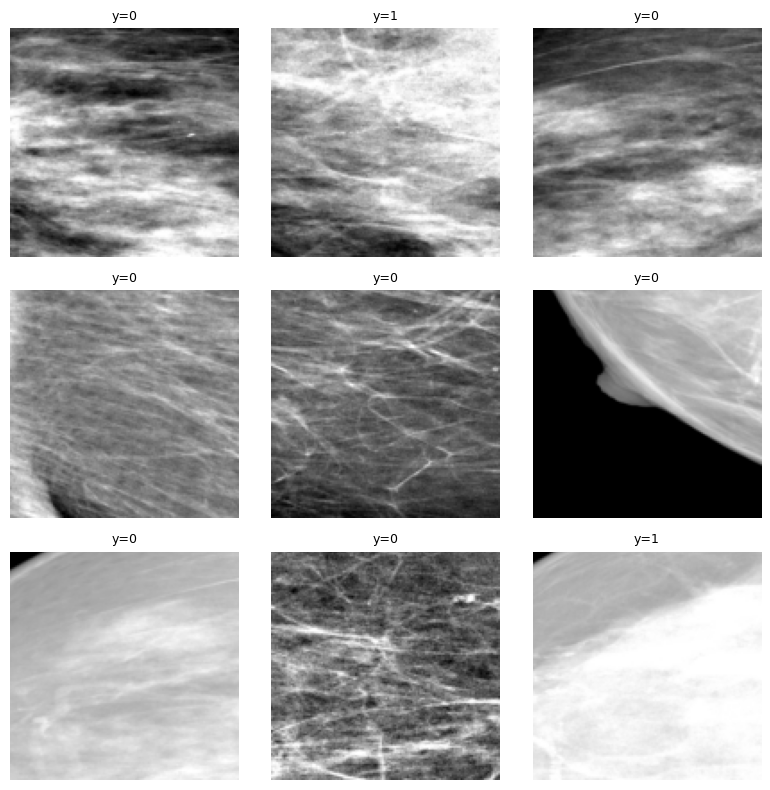

In [7]:
import matplotlib.pyplot as plt
import numpy as np

sample = patch_df.sample(n=min(9, len(patch_df)), random_state=42)

plt.figure(figsize=(8,8))
for i, r in enumerate(sample.itertuples(index=False), 1):
    img = np.load(PATCH_DIR / f"{r.patch_id}.npy")
    plt.subplot(3,3,i)
    plt.imshow(img, cmap="gray")
    plt.title(f"y={r.y_tissue}", fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

Inspecting: data\raw\inbreast\ALL-IMGS\22427705_d713ef5849f98b6c_MG_L_CC_ANON.dcm


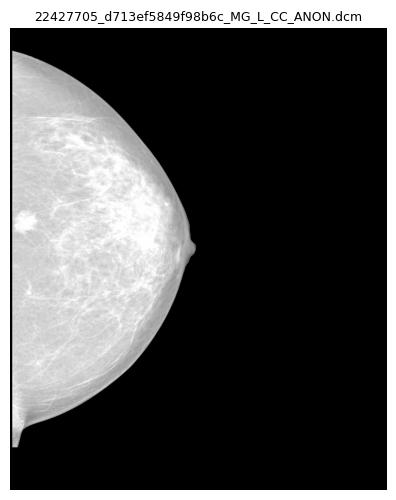

SOPClassUID               : 1.2.840.10008.5.1.4.1.1.7
SOPInstanceUID            : 1.3.6.1.4.1.9590.100.1.1.230418120812595497207085707533838928537
StudyInstanceUID          : 1.3.6.1.4.1.9590.100.1.1.265567801110730555915866494940026195954
SeriesInstanceUID         : 1.3.6.1.4.1.9590.100.1.1.360951671311898838736280044841746768125
Modality                  : OT
Manufacturer              : None
ManufacturerModelName     : None
PatientID                 : 
PatientAge                : None
PatientSex                : 
BodyPartExamined          : None
ViewPosition              : None
ImageLaterality           : None
Rows                      : 4084
Columns                   : 3328
PixelSpacing              : None
BitsAllocated             : 16
BitsStored                : 16
HighBit                   : 15
PhotometricInterpretation : MONOCHROME2
SamplesPerPixel           : 1
WindowCenter              : None
WindowWidth               : None
RescaleSlope              : None
RescaleIntercept   

,tag,keyword,vr,name,value
0,"(0008,0016)",SOPClassUID,UI,SOP Class UID,1.2.840.10008.5.1.4.1.1.7
1,"(0008,0018)",SOPInstanceUID,UI,SOP Instance UID,1.3.6.1.4.1.9590.100.1.1.230418120812595497207...
2,"(0008,0020)",StudyDate,DA,Study Date,
3,"(0008,0023)",ContentDate,DA,Content Date,20111229
4,"(0008,0030)",StudyTime,TM,Study Time,
5,"(0008,0033)",ContentTime,TM,Content Time,220054.702995
6,"(0008,0050)",AccessionNumber,SH,Accession Number,
7,"(0008,0060)",Modality,CS,Modality,OT
8,"(0008,0064)",ConversionType,CS,Conversion Type,WSD
9,"(0008,0090)",ReferringPhysicianName,PN,Referring Physician's Name,


In [8]:
import pydicom
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from pydicom.pixel_data_handlers.util import apply_voi_lut

def load_image_for_display(ds) -> np.ndarray:
    """Return a normalized [0,1] image for display."""
    img = ds.pixel_array.astype(np.float32)

    # VOI LUT if present
    try:
        img = apply_voi_lut(img, ds).astype(np.float32)
    except Exception:
        pass

    # inversion
    if getattr(ds, "PhotometricInterpretation", "") == "MONOCHROME1":
        img = img.max() - img

    lo, hi = np.percentile(img, (1, 99))
    img = np.clip(img, lo, hi)
    img = (img - lo) / (hi - lo + 1e-8)
    return img

def dicom_summary(ds) -> dict:
    """A human-readable subset of useful tags."""
    keys = [
        "SOPClassUID", "SOPInstanceUID",
        "StudyInstanceUID", "SeriesInstanceUID",
        "Modality", "Manufacturer", "ManufacturerModelName",
        "PatientID", "PatientAge", "PatientSex",
        "BodyPartExamined",
        "ViewPosition", "ImageLaterality",
        "Rows", "Columns", "PixelSpacing",
        "BitsAllocated", "BitsStored", "HighBit",
        "PhotometricInterpretation", "SamplesPerPixel",
        "WindowCenter", "WindowWidth",
        "RescaleSlope", "RescaleIntercept",
        "NumberOfFrames",
        "StudyDescription", "SeriesDescription",
    ]
    out = {}
    for k in keys:
        out[k] = getattr(ds, k, None)
    return out

def dicom_to_dataframe(ds, max_rows=None) -> pd.DataFrame:
    """Convert all DICOM tags to a table."""
    rows = []
    for elem in ds.iterall():
        tag = str(elem.tag)
        keyword = elem.keyword
        vr = elem.VR
        name = elem.name
        # Avoid huge blobs (PixelData)
        if keyword == "PixelData":
            value = f"<PixelData: {len(elem.value)} bytes>"
        else:
            v = elem.value
            s = str(v)
            if len(s) > 200:
                s = s[:200] + "..."
            value = s
        rows.append((tag, keyword, vr, name, value))

    df = pd.DataFrame(rows, columns=["tag", "keyword", "vr", "name", "value"])
    if max_rows is not None:
        df = df.head(max_rows)
    return df

# ---- Choose a file ----
IMG_DIR = Path("data/raw/inbreast/ALL-IMGS")
dicom_path = next(IMG_DIR.glob("*.dcm"))  # or set Path(".../somefile.dcm")
print("Inspecting:", dicom_path)

# ---- Read dataset ----
ds = pydicom.dcmread(str(dicom_path))

# ---- Plot image ----
img = load_image_for_display(ds)
plt.figure(figsize=(6,6))
plt.imshow(img, cmap="gray")
plt.title(dicom_path.name, fontsize=9)
plt.axis("off")
plt.show()

# ---- Print key metadata ----
summary = dicom_summary(ds)
for k, v in summary.items():
    print(f"{k:26s}: {v}")

# ---- Full metadata table (display in notebook) ----
meta_df = dicom_to_dataframe(ds)
display(meta_df)

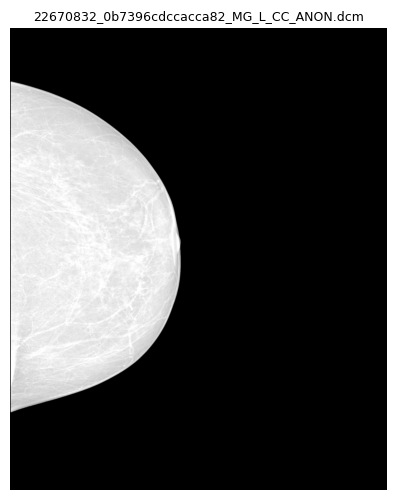

---- 22670832_0b7396cdccacca82_MG_L_CC_ANON.dcm ----
Modality              : OT
ViewPosition          : None
ImageLaterality       : None
Rows                  : 4084
Columns               : 3328
PixelSpacing          : None
PhotometricInterpretation: MONOCHROME2
WindowCenter          : None
WindowWidth           : None
StudyDescription      : None
SeriesDescription     : None



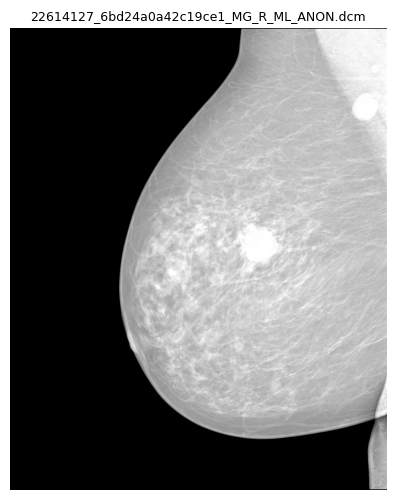

---- 22614127_6bd24a0a42c19ce1_MG_R_ML_ANON.dcm ----
Modality              : OT
ViewPosition          : None
ImageLaterality       : None
Rows                  : 4084
Columns               : 3328
PixelSpacing          : None
PhotometricInterpretation: MONOCHROME2
WindowCenter          : None
WindowWidth           : None
StudyDescription      : None
SeriesDescription     : None



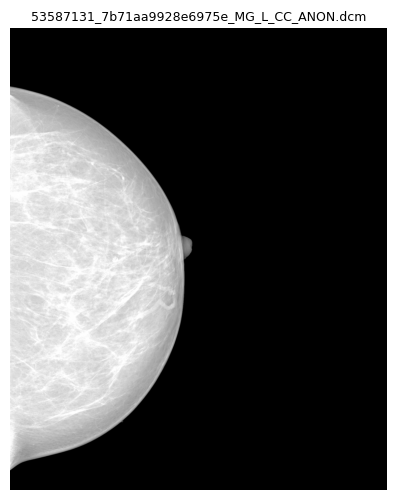

---- 53587131_7b71aa9928e6975e_MG_L_CC_ANON.dcm ----
Modality              : OT
ViewPosition          : None
ImageLaterality       : None
Rows                  : 4084
Columns               : 3328
PixelSpacing          : None
PhotometricInterpretation: MONOCHROME2
WindowCenter          : None
WindowWidth           : None
StudyDescription      : None
SeriesDescription     : None



In [9]:
import random
from pathlib import Path
import pydicom
import matplotlib.pyplot as plt

IMG_DIR = Path("data/raw/inbreast/ALL-IMGS")
dicoms = list(IMG_DIR.glob("*.dcm"))
sample = random.sample(dicoms, k=min(3, len(dicoms)))

for p in sample:
    ds = pydicom.dcmread(str(p))
    img = load_image_for_display(ds)

    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap="gray")
    plt.title(p.name, fontsize=9)
    plt.axis("off")
    plt.show()

    summary = dicom_summary(ds)
    print("----", p.name, "----")
    for k in ["Modality","ViewPosition","ImageLaterality","Rows","Columns","PixelSpacing","PhotometricInterpretation","WindowCenter","WindowWidth","StudyDescription","SeriesDescription"]:
        print(f"{k:22s}: {summary.get(k)}")
    print()

In [10]:
needle = ["acr", "birads", "bi-rads", "density", "assessment", "diagn", "mass"]

p = sample[0]
ds = pydicom.dcmread(str(p), stop_before_pixels=True)

hits = []
for elem in ds.iterall():
    key = (elem.keyword or "").lower()
    name = (elem.name or "").lower()
    if any(n in key or n in name for n in needle):
        hits.append((str(elem.tag), elem.keyword, elem.name, str(elem.value)[:120]))

pd.DataFrame(hits, columns=["tag","keyword","name","value"])

,tag,keyword,name,value


In [11]:
import pydicom
from pathlib import Path

p = next(Path("data/raw/inbreast/ALL-IMGS").glob("*.dcm"))
ds = pydicom.dcmread(str(p), stop_before_pixels=True)

print("File:", p.name)
print(ds)  # prints the whole header (excluding pixel data)

File: 22427705_d713ef5849f98b6c_MG_L_CC_ANON.dcm
Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 208
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: Secondary Capture Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.3.6.1.4.1.9590.100.1.1.230418120812595497207085707533838928537
(0002,0010) Transfer Syntax UID                 UI: Implicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.3.6.1.4.1.9590.100.1.0.100.4.0
(0002,0013) Implementation Version Name         SH: 'MATLAB IPT 4.0'
-------------------------------------------------
(0008,0016) SOP Class UID                       UI: Secondary Capture Image Storage
(0008,0018) SOP Instance UID                    UI: 1.3.6.1.4.1.9590.100.1.1.230418120812595497207085707533838928537
(0008,0020) Study Date                          DA: ''
(0008,0023) Content Date                  

In [12]:
print(ds.dir())  # list of attribute keywords present

['AccessionNumber', 'BitsAllocated', 'BitsStored', 'Columns', 'ContentDate', 'ContentTime', 'ConversionType', 'HighBit', 'InstanceNumber', 'LargestImagePixelValue', 'Modality', 'PatientBirthDate', 'PatientID', 'PatientName', 'PatientOrientation', 'PatientSex', 'PhotometricInterpretation', 'PixelRepresentation', 'ReferringPhysicianName', 'Rows', 'SOPClassUID', 'SOPInstanceUID', 'SamplesPerPixel', 'SecondaryCaptureDeviceManufacturer', 'SecondaryCaptureDeviceManufacturerModelName', 'SeriesInstanceUID', 'SeriesNumber', 'SmallestImagePixelValue', 'StudyDate', 'StudyID', 'StudyInstanceUID', 'StudyTime']


In [13]:
needle = ["acr", "birads", "bi-rads", "density", "diagn", "mass", "lesion", "assessment"]

hits = []
for elem in ds.iterall():
    kw = (elem.keyword or "").lower()
    nm = (elem.name or "").lower()
    if any(n in kw or n in nm for n in needle):
        val = elem.value
        sval = str(val)
        if len(sval) > 120:
            sval = sval[:120] + "..."
        hits.append((str(elem.tag), elem.keyword, elem.name, elem.VR, sval))

import pandas as pd
display(pd.DataFrame(hits, columns=["tag","keyword","name","vr","value"]))

,tag,keyword,name,vr,value


File: data\raw\inbreast\ALL-IMGS\22427705_d713ef5849f98b6c_MG_L_CC_ANON.dcm


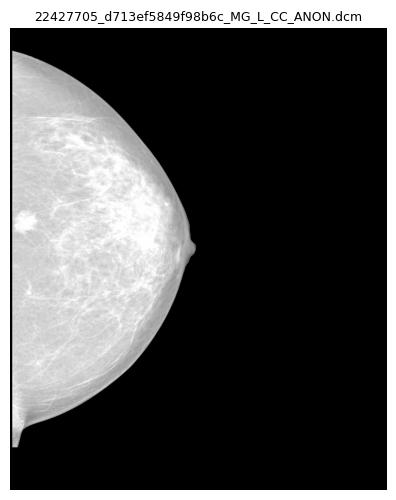

,tag,keyword,vr,name,value
0,"(0008,0016)",SOPClassUID,UI,SOP Class UID,1.2.840.10008.5.1.4.1.1.7
1,"(0008,0018)",SOPInstanceUID,UI,SOP Instance UID,1.3.6.1.4.1.9590.100.1.1.230418120812595497207...
2,"(0008,0020)",StudyDate,DA,Study Date,
3,"(0008,0023)",ContentDate,DA,Content Date,20111229
4,"(0008,0030)",StudyTime,TM,Study Time,
5,"(0008,0033)",ContentTime,TM,Content Time,220054.702995
6,"(0008,0050)",AccessionNumber,SH,Accession Number,
7,"(0008,0060)",Modality,CS,Modality,OT
8,"(0008,0064)",ConversionType,CS,Conversion Type,WSD
9,"(0008,0090)",ReferringPhysicianName,PN,Referring Physician's Name,


In [14]:
import pydicom
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from pydicom.pixel_data_handlers.util import apply_voi_lut

# ---- pick ONE file (edit this path if you want a specific one) ----
dicom_path = Path("data/raw/inbreast/ALL-IMGS")
dicom_path = next(dicom_path.glob("*.dcm"))  # first .dcm found
print("File:", dicom_path)

# ---- read DICOM ----
ds = pydicom.dcmread(str(dicom_path))

# ---- image for viewing ----
img = ds.pixel_array.astype(np.float32)

# VOI LUT (if present)
try:
    img = apply_voi_lut(img, ds).astype(np.float32)
except Exception:
    pass

# handle inversion
if getattr(ds, "PhotometricInterpretation", "") == "MONOCHROME1":
    img = img.max() - img

# robust normalisation to [0,1]
lo, hi = np.percentile(img, (1, 99))
img = np.clip(img, lo, hi)
img = (img - lo) / (hi - lo + 1e-8)

plt.figure(figsize=(6,6))
plt.imshow(img, cmap="gray")
plt.title(dicom_path.name, fontsize=9)
plt.axis("off")
plt.show()

# ---- ALL metadata as a table ----
rows = []
for elem in ds.iterall():
    tag = str(elem.tag)
    keyword = elem.keyword
    vr = elem.VR
    name = elem.name
    if keyword == "PixelData":
        try:
            value = f"<PixelData: {len(elem.value)} bytes>"
        except Exception:
            value = "<PixelData>"
    else:
        s = str(elem.value)
        if len(s) > 200:
            s = s[:200] + "..."
        value = s
    rows.append((tag, keyword, vr, name, value))

meta_df = pd.DataFrame(rows, columns=["tag", "keyword", "vr", "name", "value"])
display(meta_df)